In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.optimizers import Adam
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from keras.utils import plot_model, to_categorical, normalize
from random import randint

In [32]:
(train_X, train_y), (test_X, test_y) = mnist.load_data()

print('X_train: ' + str(train_X.shape))
print('Y_train: ' + str(train_y.shape))
print('X_test:  '  + str(test_X.shape))
print('Y_test:  '  + str(test_y.shape))

X_train: (60000, 28, 28)
Y_train: (60000,)
X_test:  (10000, 28, 28)
Y_test:  (10000,)


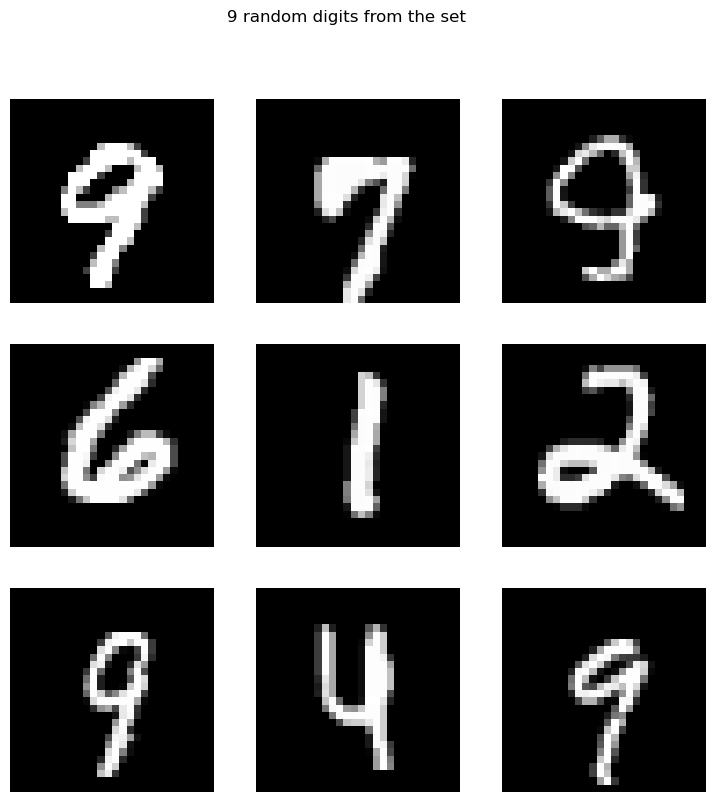

In [33]:
ix = [randint(0, train_X.shape[0] - 1) for _ in range(9)]
plt.figure( figsize=(9,9) )
plt.suptitle( "9 random digits from the set" )
for pos, i  in enumerate(ix):
    plt.subplot(3, 3, pos+1)
    plt.imshow(train_X[i], cmap="gray")
    plt.axis("off")
plt.show()

Data normalization, so it is easier for the model to perform calculations.  
Reshaping the data, so we have 2D data instead of 3D


In [34]:
train_X =  normalize(train_X)
test_X = normalize(test_X)

train_X = train_X.reshape( train_X.shape[0], train_X.shape[1] ** 2)
test_X = test_X.reshape( test_X.shape[0], test_X.shape[1] ** 2)

print('X_train (after flattening): ' + str(train_X.shape))
print('X_test (after flattening):  '  + str(test_X.shape))


X_train (after flattening): (60000, 784)
X_test (after flattening):  (10000, 784)


In [35]:

model = Sequential([
    Dense( 128, input_shape = (28*28, ), activation = "relu", name = "L1"),
    Dense( 64, activation = "sigmoid", name = "L2"),
    Dense( 10, activation = "softmax", name = "L3")
])

model.compile( optimizer = 'adam',
               loss = 'sparse_categorical_crossentropy',
               metrics = ['accuracy'] )

model.fit(train_X, train_y, epochs = 10)

Epoch 1/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.3855 - accuracy: 0.8968
Epoch 2/10
1875/1875 [==============================] - 3s 2ms/step - loss: 0.1412 - accuracy: 0.9580
Epoch 3/10
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0952 - accuracy: 0.9718
Epoch 4/10
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0708 - accuracy: 0.9787
Epoch 5/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0553 - accuracy: 0.9834
Epoch 6/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0428 - accuracy: 0.9869
Epoch 7/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0341 - accuracy: 0.9899
Epoch 8/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0275 - accuracy: 0.9922
Epoch 9/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0232 - accuracy: 0.9931
Epoch 10/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.018

Model evaluation

In [36]:
pred_y = model.predict(test_X)
loss, accuracy = model.evaluate(test_X, test_y)

print(f"Model's loss: {loss}")
print(f"Model's accuracy: {accuracy}")

313/313 [==============================] - 1s 2ms/step - loss: 0.0884 - accuracy: 0.9750
Model's loss: 0.0884188860654831
Model's accuracy: 0.9750000238418579


Let's take a look at misclasified objects

In [37]:
missclasified_idx = np.where(pred_y != test_y)[0]
print(missclasified_idx)

[0]


C:\Users\Użytkownik\AppData\Local\Temp\ipykernel_9672\1413659458.py:1: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  missclasified_idx = np.where(pred_y != test_y)[0]
